# Extension 3 - Route Optimization for Rotor Gain

## Goal
Given historical metocean statistics across the North Sea, find the route between two ports that **maximises the integrated Flettner rotor power contribution** - i.e. the route that spends the most time in high-gain wind conditions.

## Approach
1. Build a spatial rotor-gain map from historical observations (1°×1° grid).
2. Identify a representative voyage and generate a family of candidate routes.
3. Use Dijkstra's algorithm on a finer grid to find the globally optimal detour.
4. Analyse seasonal sensitivity - optimal routes in winter vs spring vs summer.
5. Identify the best departure month for the chosen origin–destination pair.

## 0. Setup

In [9]:
import warnings
warnings.filterwarnings('ignore')

import heapq
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from scipy.interpolate import RegularGridInterpolator

plt.style.use('seaborn-v0_8-darkgrid')

DATA_PATH    = '../data/MasterSet_features.csv'
RESULTS_PATH = '../results/'

df = pd.read_csv(DATA_PATH, parse_dates=['Time'])
df = df.sort_values('Time').reset_index(drop=True)
df['month'] = df['Time'].dt.month
df['hour']  = df['Time'].dt.hour

print(f"Loaded {len(df):,} rows, {df['Voyage_ID'].nunique()} voyages")
print(f"Time range: {df['Time'].min().date()} → {df['Time'].max().date()}")
print(f"Lat: {df['Lat'].min():.2f}°N – {df['Lat'].max():.2f}°N")
print(f"Lon: {df['Lon'].min():.2f}°E – {df['Lon'].max():.2f}°E")

Loaded 125,160 rows, 528 voyages
Time range: 2023-02-02 → 2026-02-02
Lat: 51.04°N – 61.23°N
Lon: -2.12°E – 11.20°E


## Rotor Polar Diagram Utility

In [10]:
WIND_SPEEDS = np.array([4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24])
WIND_ANGLES = np.array([0, 20, 40, 60, 80, 90, 100, 120, 140, 160, 180])
POWER_TABLE = np.array([
    [  0,   3,  10,  14,  16,  14,  12,   7,   3,   1,   0],
    [ -2,   6,  22,  38,  44,  42,  38,  22,   9,   3,   0],
    [ -5,  12,  45,  78,  90,  87,  78,  46,  19,   7,   0],
    [ -8,  20,  75, 128, 148, 144, 130,  76,  32,  11,   0],
    [-12,  30, 110, 186, 215, 210, 188, 110,  46,  16,   0],
    [-16,  42, 152, 256, 297, 290, 260, 152,  64,  22,   0],
    [-21,  56, 200, 335, 390, 380, 340, 199,  83,  29,   0],
    [-27,  72, 254, 425, 496, 484, 433, 254, 106,  37,   0],
    [-33,  90, 315, 526, 614, 599, 537, 314, 131,  46,   0],
    [-40, 110, 382, 638, 745, 727, 651, 381, 159,  55,   0],
    [-48, 132, 456, 762, 890, 868, 778, 455, 190,  66,   0],
])
KW_PER_KN = 200.0

_interp = RegularGridInterpolator(
    (WIND_SPEEDS, WIND_ANGLES), POWER_TABLE,
    method='linear', bounds_error=False, fill_value=None
)

def rotor_power_kw(wind_ms, alpha_abs):
    ws = np.clip(np.asarray(wind_ms, float), WIND_SPEEDS.min(), WIND_SPEEDS.max())
    wa = np.clip(np.asarray(alpha_abs, float), WIND_ANGLES.min(), WIND_ANGLES.max())
    return _interp(np.column_stack([ws.ravel(), wa.ravel()])).reshape(ws.shape)


def haversine_nm(lat1, lon1, lat2, lon2):
    R = 3440.065
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi    = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlambda/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))


def normalize_angle(angle_deg):
    return ((angle_deg + 180) % 360) - 180


# Sanity check
print(f"Rotor power @ 10 m/s, 90° (abeam):     {rotor_power_kw(10, 90):.1f} kW")
print(f"Rotor power @ 10 m/s, 0°  (headwind):  {rotor_power_kw(10, 0):.1f} kW")
print(f"Rotor power @ 16 m/s, 80° (best angle): {rotor_power_kw(16, 80):.1f} kW")

Rotor power @ 10 m/s, 90° (abeam):     144.0 kW
Rotor power @ 10 m/s, 0°  (headwind):  -8.0 kW
Rotor power @ 16 m/s, 80° (best angle): 390.0 kW


## 1. Metocean Spatial Field

Compute per-grid-cell mean rotor power using historical observations. This acts as a climatological proxy for the expected rotor benefit at each location.

In [11]:
lat_bins = np.arange(50, 62, 1)   # 50–61°N, 11 bins
lon_bins = np.arange(-3, 12, 1)   # -3–11°E, 14 bins

df['lat_cell'] = pd.cut(df['Lat'], bins=lat_bins, labels=lat_bins[:-1] + 0.5).astype(float)
df['lon_cell'] = pd.cut(df['Lon'], bins=lon_bins, labels=lon_bins[:-1] + 0.5).astype(float)

# Compute rotor power for every observation
df['rotor_power_kw'] = rotor_power_kw(
    df['True_Wind_Speed_ms'].values,
    df['alpha_abs_deg'].values
)

grid_stats = (
    df.groupby(['lat_cell', 'lon_cell'], observed=True)
    .agg(
        mean_rotor_power  = ('rotor_power_kw', 'mean'),
        median_wind_speed = ('True_Wind_Speed_ms', 'median'),
        mean_alpha_abs    = ('alpha_abs_deg', 'mean'),
        mean_hs           = ('H_s', 'mean'),
        n_obs             = ('Speed_kn', 'count'),
    )
    .reset_index()
)

print(f"Grid cells with data: {len(grid_stats)}")
print(f"Mean rotor power across grid: {grid_stats['mean_rotor_power'].mean():.1f} kW")
print(f"Max mean rotor power in a cell: {grid_stats['mean_rotor_power'].max():.1f} kW")
print(f"\nTop 5 cells by rotor gain:")
print(grid_stats.nlargest(5, 'mean_rotor_power')[['lat_cell','lon_cell','mean_rotor_power','median_wind_speed','mean_alpha_abs']].to_string(index=False))

Grid cells with data: 72
Mean rotor power across grid: 78.5 kW
Max mean rotor power in a cell: 292.4 kW

Top 5 cells by rotor gain:
 lat_cell  lon_cell  mean_rotor_power  median_wind_speed  mean_alpha_abs
     58.5       0.5        292.404770          18.209806      117.110030
     58.5       1.5        226.411758          16.793715      115.701881
     54.5      -0.5        182.259681          12.761848       67.348162
     55.5       7.5        180.780673          12.555180       60.605847
     56.5      -0.5        176.630924          12.846293       69.541275


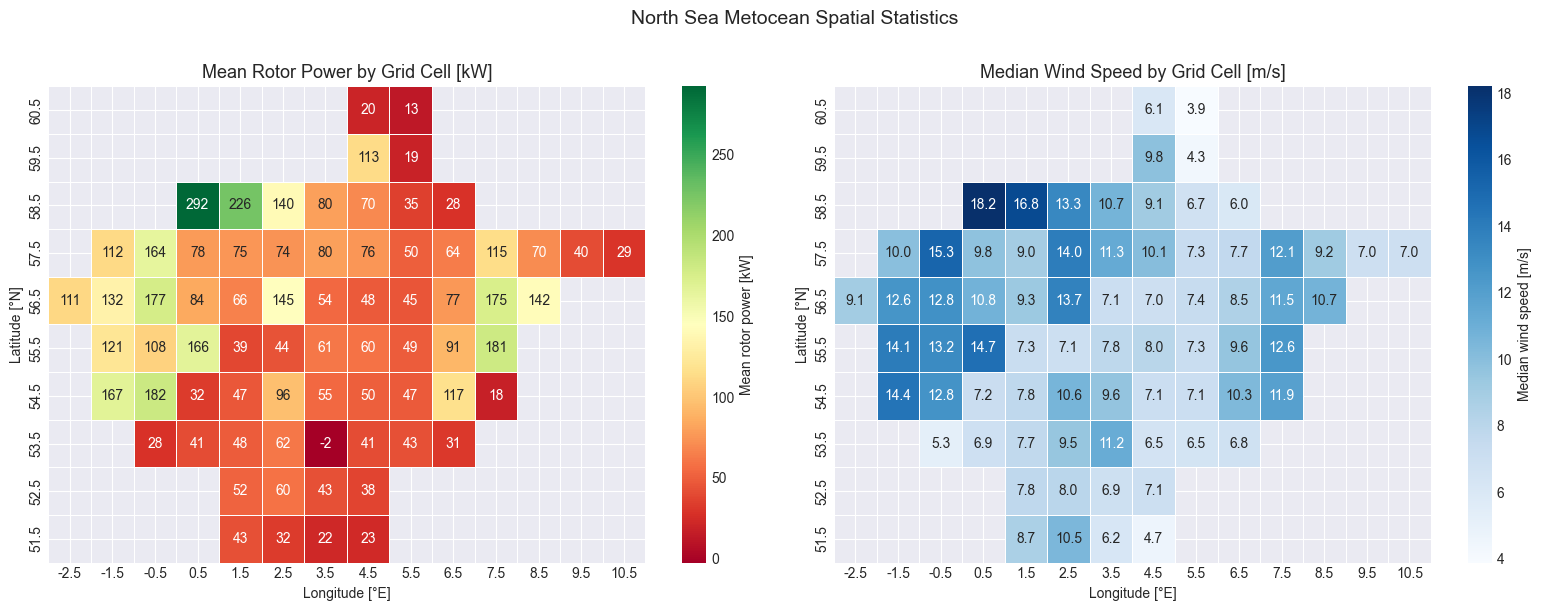

In [12]:
pivot_power = grid_stats.pivot(index='lat_cell', columns='lon_cell', values='mean_rotor_power')
pivot_wind  = grid_stats.pivot(index='lat_cell', columns='lon_cell', values='median_wind_speed')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(
    pivot_power.sort_index(ascending=False),
    ax=axes[0], annot=True, fmt='.0f', cmap='RdYlGn',
    cbar_kws={'label': 'Mean rotor power [kW]'},
    linewidths=0.5, linecolor='white'
)
axes[0].set_title('Mean Rotor Power by Grid Cell [kW]', fontsize=13)
axes[0].set_xlabel('Longitude [°E]')
axes[0].set_ylabel('Latitude [°N]')

sns.heatmap(
    pivot_wind.sort_index(ascending=False),
    ax=axes[1], annot=True, fmt='.1f', cmap='Blues',
    cbar_kws={'label': 'Median wind speed [m/s]'},
    linewidths=0.5, linecolor='white'
)
axes[1].set_title('Median Wind Speed by Grid Cell [m/s]', fontsize=13)
axes[1].set_xlabel('Longitude [°E]')
axes[1].set_ylabel('Latitude [°N]')

plt.suptitle('North Sea Metocean Spatial Statistics', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 2. Voyage-Level Routing Setup

Select the test-set voyage with the highest mean rotor gain as the reference OD pair.

In [13]:
# Voyage-based chronological split (same as baseline_model.ipynb)
voyage_order = (
    df.groupby('Voyage_ID')['Time'].min()
    .sort_values()
    .index.tolist()
)
split_idx    = int(len(voyage_order) * 0.8)
test_voyages = set(voyage_order[split_idx:])
df_test      = df[df['Voyage_ID'].isin(test_voyages)].copy()

# Per-voyage mean rotor gain
voyage_gain = (
    df_test.groupby('Voyage_ID')
    .agg(
        mean_rotor_kw = ('rotor_power_kw', 'mean'),
        n_pts         = ('Speed_kn', 'count'),
        start_lat     = ('Lat', 'first'),
        start_lon     = ('Lon', 'first'),
        end_lat       = ('Lat', 'last'),
        end_lon       = ('Lon', 'last'),
    )
    .reset_index()
)

# Filter: voyages with meaningful length difference between start and end
voyage_gain['lat_span'] = (voyage_gain['end_lat'] - voyage_gain['start_lat']).abs()
best_voyage = voyage_gain[voyage_gain['lat_span'] > 2].nlargest(1, 'mean_rotor_kw').iloc[0]

VID       = int(best_voyage['Voyage_ID'])
start_lat = best_voyage['start_lat']
start_lon = best_voyage['start_lon']
end_lat   = best_voyage['end_lat']
end_lon   = best_voyage['end_lon']

v_data = df_test[df_test['Voyage_ID'] == VID].copy()
actual_dist = haversine_nm(start_lat, start_lon, end_lat, end_lon)

print(f"Reference voyage: {VID}")
print(f"  Start: ({start_lat:.3f}°N, {start_lon:.3f}°E)")
print(f"  End:   ({end_lat:.3f}°N, {end_lon:.3f}°E)")
print(f"  Great-circle distance: {actual_dist:.1f} nm")
print(f"  Mean rotor power: {best_voyage['mean_rotor_kw']:.1f} kW")
print(f"  Mean rotor delta_SOG: {best_voyage['mean_rotor_kw']/KW_PER_KN:.3f} kn")
print(f"  Observations: {int(best_voyage['n_pts'])}")

Reference voyage: 456
  Start: (51.890°N, 4.402°E)
  End:   (61.226°N, 7.683°E)
  Great-circle distance: 570.7 nm
  Mean rotor power: 148.3 kW
  Mean rotor delta_SOG: 0.741 kn
  Observations: 513


## 3. Candidate Route Generation

Compare 9 routes (direct + 8 longitude detours at the midpoint) against the same OD pair.

In [14]:
# Lookup table: mean wind conditions per 1° grid cell (all data)
grid_lookup = grid_stats.set_index(['lat_cell', 'lon_cell'])
GLOBAL_WIND  = df['True_Wind_Speed_ms'].mean()
GLOBAL_ALPHA = df['alpha_abs_deg'].mean()
GLOBAL_HS    = df['H_s'].mean()

def cell_wind_conditions(lat, lon):
    """Return (wind_ms, alpha_abs, hs) for the 1° cell containing (lat, lon)."""
    lat_c = lat_bins[np.searchsorted(lat_bins, lat, side='right') - 1] + 0.5
    lon_c = lon_bins[np.searchsorted(lon_bins, lon, side='right') - 1] + 0.5
    lat_c = np.clip(lat_c, lat_bins[0]+0.5, lat_bins[-2]+0.5)
    lon_c = np.clip(lon_c, lon_bins[0]+0.5, lon_bins[-2]+0.5)
    try:
        row = grid_lookup.loc[(lat_c, lon_c)]
        return row['median_wind_speed'], row['mean_alpha_abs'], row['mean_hs']
    except KeyError:
        return GLOBAL_WIND, GLOBAL_ALPHA, GLOBAL_HS


def interpolate_route(waypoints, n_pts=50):
    """Interpolate N points along a piecewise linear route."""
    lats, lons = zip(*waypoints)
    pts = []
    seg_lengths = [haversine_nm(lats[i], lons[i], lats[i+1], lons[i+1]) for i in range(len(lats)-1)]
    total_len = sum(seg_lengths)
    for i in range(len(lats) - 1):
        n_seg = max(2, int(round(n_pts * seg_lengths[i] / total_len)))
        for t in np.linspace(0, 1, n_seg, endpoint=(i == len(lats)-2)):
            pts.append((lats[i] + t*(lats[i+1]-lats[i]),
                        lons[i] + t*(lons[i+1]-lons[i])))
    return pts


def evaluate_route(waypoints, n_pts=50):
    """Compute rotor metrics along a route defined by waypoints."""
    pts     = interpolate_route(waypoints, n_pts)
    n       = len(pts)
    powers  = []
    hs_vals = []
    dist    = 0.0

    for idx, (lat, lon) in enumerate(pts):
        wind_ms, _, hs = cell_wind_conditions(lat, lon)

        # Course to next point
        if idx < n - 1:
            dlat = pts[idx+1][0] - lat
            dlon = pts[idx+1][1] - lon
            course_rad = np.arctan2(dlon * np.cos(np.radians(lat)), dlat)
            course_deg = np.degrees(course_rad) % 360
        # Use cached mean wind_dir for alpha estimation
        mean_wind_dir = df['wind_dir_deg'].mean()
        alpha_abs = abs(normalize_angle(mean_wind_dir - course_deg))

        power = rotor_power_kw(wind_ms, alpha_abs)
        powers.append(float(power))
        hs_vals.append(hs)

        if idx < n - 1:
            dist += haversine_nm(lat, lon, pts[idx+1][0], pts[idx+1][1])

    active      = [(p > 0 and h <= 6.0) for p, h in zip(powers, hs_vals)]
    active_pwr  = [p for p, a in zip(powers, active) if a]
    mean_pwr    = np.mean(active_pwr) if active_pwr else 0.0
    mean_gain   = mean_pwr / KW_PER_KN
    return dist, mean_pwr, mean_gain


# --- Candidate routes ---
lat_mid = (start_lat + end_lat) / 2
lon_mid = (start_lon + end_lon) / 2

detours = [0.0, -2.0, -1.5, -1.0, -0.5, 0.5, 1.0, 1.5, 2.0]
routes  = []

direct_dist, _, _ = evaluate_route([(start_lat, start_lon), (end_lat, end_lon)])

for d in detours:
    wpts  = [(start_lat, start_lon), (lat_mid, lon_mid + d), (end_lat, end_lon)]
    dist, mean_pwr, mean_gain = evaluate_route(wpts)
    label = 'Direct' if d == 0 else f'{d:+.1f}° lon'
    routes.append({
        'label':           label,
        'detour_lon':      d,
        'waypoints':       wpts,
        'distance_nm':     dist,
        'extra_nm':        dist - direct_dist,
        'mean_power_kw':   mean_pwr,
        'mean_gain_kn':    mean_gain,
        'net_benefit':     mean_gain * dist,
    })

routes_df = pd.DataFrame(routes).sort_values('mean_power_kw', ascending=False)
print("Candidate route comparison:")
print(routes_df[['label','distance_nm','extra_nm','mean_power_kw','mean_gain_kn','net_benefit']]
      .to_string(index=False, float_format='{:.2f}'.format))

Candidate route comparison:
    label  distance_nm  extra_nm  mean_power_kw  mean_gain_kn  net_benefit
+2.0° lon       588.50     17.54           5.55          0.03        16.34
+1.5° lon       581.46     10.50           4.04          0.02        11.73
-2.0° lon       582.71     11.75           3.31          0.02         9.66
+1.0° lon       576.15      5.19           3.00          0.02         8.65
-1.5° lon       577.02      6.06           2.34          0.01         6.74
-1.0° lon       573.15      2.19           2.14          0.01         6.13
+0.5° lon       572.64      1.68           2.03          0.01         5.82
-0.5° lon       571.13      0.17           1.93          0.01         5.50
   Direct       570.96     -0.00           1.92          0.01         5.47


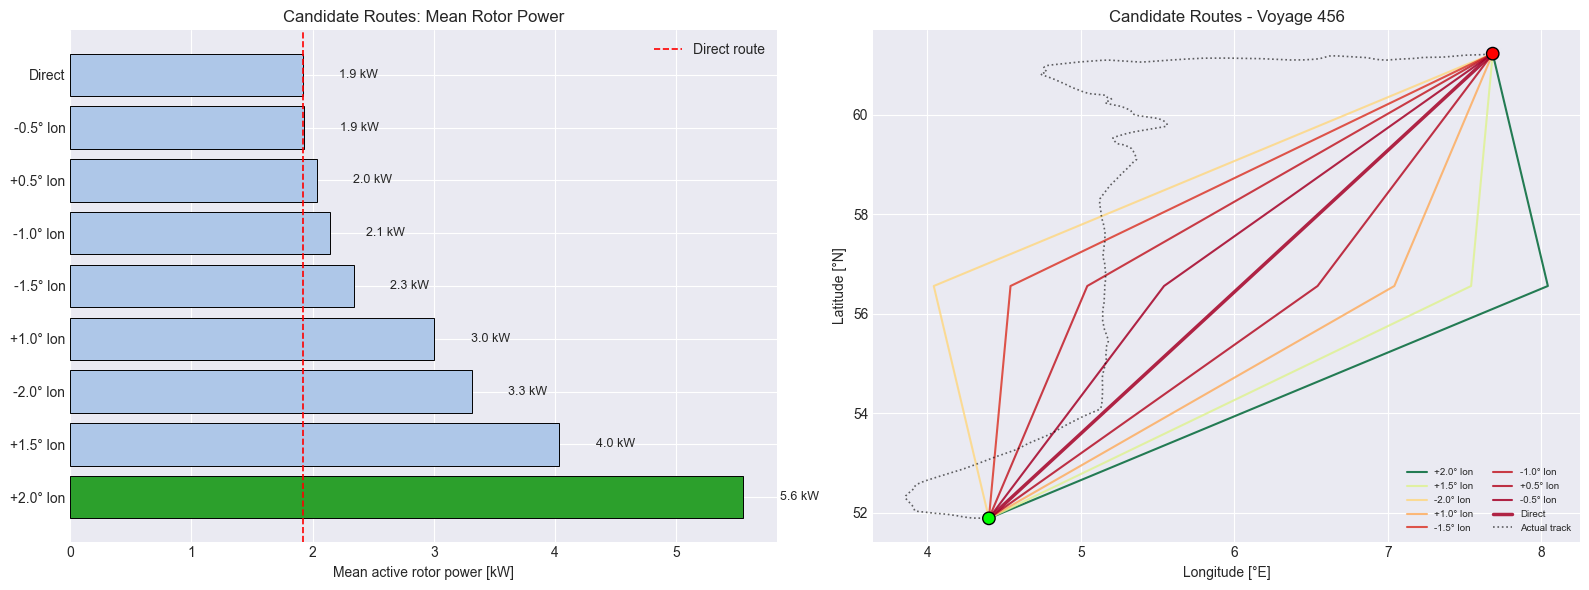

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart of mean rotor power
colors = ['#2ca02c' if r == routes_df.iloc[0]['label'] else '#aec7e8' for r in routes_df['label']]
axes[0].barh(routes_df['label'], routes_df['mean_power_kw'], color=colors, edgecolor='black', linewidth=0.7)
axes[0].axvline(routes_df[routes_df['label']=='Direct']['mean_power_kw'].values[0],
                color='red', linestyle='--', linewidth=1.2, label='Direct route')
axes[0].set_xlabel('Mean active rotor power [kW]')
axes[0].set_title('Candidate Routes: Mean Rotor Power')
axes[0].legend()
for i, (_, row) in enumerate(routes_df.iterrows()):
    axes[0].text(row['mean_power_kw'] + 0.3, i, f"{row['mean_power_kw']:.1f} kW", va='center', fontsize=9)

# Route map
cmap   = plt.cm.RdYlGn
min_pw = routes_df['mean_power_kw'].min()
max_pw = routes_df['mean_power_kw'].max()
for _, row in routes_df.iterrows():
    pts  = interpolate_route(row['waypoints'])
    lats, lons = zip(*pts)
    norm_val   = (row['mean_power_kw'] - min_pw) / max(max_pw - min_pw, 1)
    lw   = 2.5 if row['label'] == 'Direct' else 1.5
    axes[1].plot(lons, lats, color=cmap(norm_val), linewidth=lw,
                 alpha=0.85, label=row['label'])

# Actual vessel track
axes[1].plot(v_data['Lon'], v_data['Lat'], 'k:', linewidth=1.2, alpha=0.6, label='Actual track')
axes[1].scatter([start_lon, end_lon], [start_lat, end_lat],
                color=['lime','red'], s=80, zorder=5, edgecolor='black')
axes[1].set_xlabel('Longitude [°E]')
axes[1].set_ylabel('Latitude [°N]')
axes[1].set_title(f'Candidate Routes - Voyage {VID}')
axes[1].legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.show()

## 4. Dijkstra-Based Grid Routing

Build a 0.5° graph over the North Sea and find the globally optimal route that maximises rotor gain while minimising unnecessary detour.

In [ ]:
# ---- Build fine grid ----
GRID_STEP  = 0.5
grid_lats  = np.arange(51, 61 + GRID_STEP, GRID_STEP)
grid_lons  = np.arange(-2, 11 + GRID_STEP, GRID_STEP)
DIST_PENALTY = 0.1   # nm penalty weight vs kW gain
DEFAULT_PWR  = 30.0  # kW for cells without data

# Build per-node rotor power lookup (½° resolution, interpolated from 1° grid)
def node_rotor_power(lat, lon):
    """Rotor power at a grid node, using nearest 1° cell statistics."""
    lat_c = lat_bins[np.searchsorted(lat_bins, lat, side='right') - 1] + 0.5
    lon_c = lon_bins[np.searchsorted(lon_bins, lon, side='right') - 1] + 0.5
    lat_c = np.clip(lat_c, lat_bins[0]+0.5, lat_bins[-2]+0.5)
    lon_c = np.clip(lon_c, lon_bins[0]+0.5, lon_bins[-2]+0.5)
    try:
        return float(grid_lookup.loc[(lat_c, lon_c), 'mean_rotor_power'])
    except KeyError:
        return DEFAULT_PWR


def nearest_node(lat, lon, lats, lons):
    i = int(np.argmin(np.abs(lats - lat)))
    j = int(np.argmin(np.abs(lons - lon)))
    return (i, j)


def dijkstra_max_rotor(start_lat, start_lon, end_lat, end_lon,
                       grid_lats, grid_lons, dist_penalty=DIST_PENALTY):
    """Dijkstra maximising rotor gain minus distance penalty."""
    ni, nj     = len(grid_lats), len(grid_lons)
    src        = nearest_node(start_lat, start_lon, grid_lats, grid_lons)
    dst        = nearest_node(end_lat,   end_lon,   grid_lats, grid_lons)

    # cost = -gain + dist_penalty (minimise negative gain + distance)
    dist_map = {src: 0.0}
    prev_map = {src: None}
    heap     = [(0.0, src)]

    directions = [(-1,-1),(-1,0),(-1,1),(0,-1),(0,1),(1,-1),(1,0),(1,1)]

    while heap:
        cost, node = heapq.heappop(heap)
        if node == dst:
            break
        if cost > dist_map.get(node, float('inf')):
            continue
        i, j = node
        for di, dj in directions:
            ni2, nj2 = i + di, j + dj
            if 0 <= ni2 < ni and 0 <= nj2 < nj:
                nb = (ni2, nj2)
                d  = haversine_nm(grid_lats[i], grid_lons[j],
                                  grid_lats[ni2], grid_lons[nj2])
                pwr = (node_rotor_power(grid_lats[i],  grid_lons[j]) +
                       node_rotor_power(grid_lats[ni2], grid_lons[nj2])) / 2
                # gain per nm, then scale to edge distance; subtract = maximise
                edge_cost = -pwr + dist_penalty * d
                new_cost  = dist_map[node] + edge_cost
                if new_cost < dist_map.get(nb, float('inf')):
                    dist_map[nb] = new_cost
                    prev_map[nb] = node
                    heapq.heappush(heap, (new_cost, nb))

    # Reconstruct path
    path, cur = [], dst
    while cur is not None:
        path.append(cur)
        cur = prev_map.get(cur)
    path.reverse()
    coords = [(grid_lats[i], grid_lons[j]) for i, j in path]
    return coords


optimal_path = dijkstra_max_rotor(start_lat, start_lon, end_lat, end_lon,
                                  grid_lats, grid_lons)

# Evaluate optimal vs direct
direct_dist_d, direct_pwr_d, direct_gain_d = evaluate_route(
    [(start_lat, start_lon), (end_lat, end_lon)], n_pts=80)
opt_dist_d, opt_pwr_d, opt_gain_d = evaluate_route(optimal_path, n_pts=80)

print(f"Optimal path: {len(optimal_path)} nodes")
print(f"  Distance:         {opt_dist_d:.1f} nm  (direct: {direct_dist_d:.1f} nm, detour: +{opt_dist_d - direct_dist_d:.1f} nm)")
print(f"  Mean rotor power: {opt_pwr_d:.1f} kW  (direct: {direct_pwr_d:.1f} kW)")
print(f"  Mean delta_SOG:   {opt_gain_d:.3f} kn  (direct: {direct_gain_d:.3f} kn)")
if direct_pwr_d > 0:
    print(f"  Gain improvement: {(opt_pwr_d - direct_pwr_d) / direct_pwr_d * 100:+.1f}%")

In [ ]:
fig, ax = plt.subplots(figsize=(12, 9))

# Rotor power heatmap as background
lon_mesh, lat_mesh = np.meshgrid(grid_lons, grid_lats)
power_grid = np.array([
    [node_rotor_power(la, lo) for lo in grid_lons]
    for la in grid_lats
])
c = ax.pcolormesh(lon_mesh, lat_mesh, power_grid,
                  cmap='RdYlGn', alpha=0.55, shading='nearest',
                  vmin=power_grid.min(), vmax=power_grid.max())
plt.colorbar(c, ax=ax, label='Mean rotor power [kW]', shrink=0.7)

# Routes
direct_pts = interpolate_route([(start_lat, start_lon), (end_lat, end_lon)], n_pts=80)
d_lats, d_lons = zip(*direct_pts)
ax.plot(d_lons, d_lats, 'b--', linewidth=2.0, label='Direct route', zorder=3)

opt_lats, opt_lons = zip(*optimal_path)
ax.plot(opt_lons, opt_lats, 'darkgreen', linewidth=2.5, label='Dijkstra-optimal route', zorder=4)

ax.plot(v_data['Lon'], v_data['Lat'], 'k:', linewidth=1.5, alpha=0.7,
        label=f'Actual track (voyage {VID})', zorder=2)

ax.scatter([start_lon, end_lon], [start_lat, end_lat],
           color=['lime', 'red'], s=120, zorder=6, edgecolor='black',
           label='Start / End')

ax.set_xlabel('Longitude [°E]', fontsize=12)
ax.set_ylabel('Latitude [°N]', fontsize=12)
ax.set_title(f'Dijkstra Optimal Route vs Direct - Voyage {VID}\n'
             f'Optimal: {opt_pwr_d:.1f} kW vs Direct: {direct_pwr_d:.1f} kW '
             f'(detour +{opt_dist_d - direct_dist_d:.1f} nm)', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 5. Seasonal Sensitivity Analysis

Wind patterns in the North Sea vary strongly by season. Does the optimal route change?

In [ ]:
seasons = {
    'Winter (Dec–Feb)': [12, 1, 2],
    'Spring (Mar–May)': [3, 4, 5],
    'Summer (Jun–Aug)': [6, 7, 8],
}
season_colors = {'Winter (Dec–Feb)': 'steelblue',
                 'Spring (Mar–May)': 'seagreen',
                 'Summer (Jun–Aug)': 'darkorange'}

seasonal_results = []

for season_name, months in seasons.items():
    df_s = df[df['month'].isin(months)]
    if len(df_s) < 100:
        continue

    gs_s = (
        df_s.groupby(['lat_cell', 'lon_cell'], observed=True)
        .agg(mean_rotor_power=('rotor_power_kw','mean'),
             mean_hs=('H_s','mean'))
        .reset_index()
        .set_index(['lat_cell','lon_cell'])
    )

    def seasonal_power(lat, lon):
        lat_c = lat_bins[np.searchsorted(lat_bins, lat, side='right') - 1] + 0.5
        lon_c = lon_bins[np.searchsorted(lon_bins, lon, side='right') - 1] + 0.5
        lat_c = np.clip(lat_c, lat_bins[0]+0.5, lat_bins[-2]+0.5)
        lon_c = np.clip(lon_c, lon_bins[0]+0.5, lon_bins[-2]+0.5)
        try:
            return float(gs_s.loc[(lat_c, lon_c), 'mean_rotor_power'])
        except KeyError:
            return DEFAULT_PWR

    # Override node_rotor_power for this season via lambda (local scope trick)
    original_fn = node_rotor_power
    _local_power = seasonal_power  # keep reference

    # Run Dijkstra with seasonal grid
    def dijkstra_seasonal(start_lat, start_lon, end_lat, end_lon, power_fn):
        ni2, nj2_ = len(grid_lats), len(grid_lons)
        src = nearest_node(start_lat, start_lon, grid_lats, grid_lons)
        dst = nearest_node(end_lat, end_lon, grid_lats, grid_lons)
        dist_map = {src: 0.0}
        prev_map = {src: None}
        heap     = [(0.0, src)]
        dirs     = [(-1,-1),(-1,0),(-1,1),(0,-1),(0,1),(1,-1),(1,0),(1,1)]
        while heap:
            cost, node = heapq.heappop(heap)
            if node == dst: break
            if cost > dist_map.get(node, float('inf')): continue
            i, j = node
            for di, dj in dirs:
                i2, j2 = i+di, j+dj
                if 0 <= i2 < len(grid_lats) and 0 <= j2 < len(grid_lons):
                    nb = (i2, j2)
                    d  = haversine_nm(grid_lats[i], grid_lons[j],
                                     grid_lats[i2], grid_lons[j2])
                    pwr = (power_fn(grid_lats[i],  grid_lons[j]) +
                           power_fn(grid_lats[i2], grid_lons[j2])) / 2
                    ec = -pwr + DIST_PENALTY * d
                    nc = dist_map[node] + ec
                    if nc < dist_map.get(nb, float('inf')):
                        dist_map[nb] = nc
                        prev_map[nb] = node
                        heapq.heappush(heap, (nc, nb))
        path, cur = [], dst
        while cur is not None:
            path.append(cur)
            cur = prev_map.get(cur)
        path.reverse()
        return [(grid_lats[i], grid_lons[j]) for i, j in path]

    opt_path_s = dijkstra_seasonal(start_lat, start_lon, end_lat, end_lon, _local_power)
    s_dist, s_pwr, s_gain = evaluate_route(opt_path_s, n_pts=80)
    d_dist, d_pwr, d_gain = evaluate_route([(start_lat,start_lon),(end_lat,end_lon)], n_pts=80)

    seasonal_results.append({
        'season':           season_name,
        'direct_power_kw':  d_pwr,
        'optimal_power_kw': s_pwr,
        'improvement_pct':  (s_pwr - d_pwr) / max(d_pwr, 1) * 100,
        'detour_nm':        s_dist - d_dist,
        'path':             opt_path_s,
    })
    print(f"{season_name}: direct={d_pwr:.1f} kW, optimal={s_pwr:.1f} kW, "
          f"improvement={s_pwr-d_pwr:+.1f} kW, detour=+{s_dist-d_dist:.1f} nm")

sr_df = pd.DataFrame(seasonal_results).drop(columns='path')
print("\nSeasonal comparison table:")
print(sr_df.to_string(index=False, float_format='{:.2f}'.format))

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Route map with all 3 seasonal optimals
c2 = axes[0].pcolormesh(lon_mesh, lat_mesh, power_grid,
                        cmap='RdYlGn', alpha=0.45, shading='nearest')
plt.colorbar(c2, ax=axes[0], label='Mean rotor power [kW]', shrink=0.7)

# Direct route
axes[0].plot(d_lons, d_lats, 'k--', linewidth=1.8, alpha=0.6, label='Direct', zorder=2)

for res in seasonal_results:
    pl, po = zip(*res['path'])
    axes[0].plot(po, pl, linewidth=2.5,
                 color=season_colors[res['season']],
                 label=res['season'], zorder=3)

axes[0].scatter([start_lon, end_lon], [start_lat, end_lat],
                color=['lime','red'], s=100, zorder=5, edgecolor='black')
axes[0].set_xlabel('Longitude [°E]')
axes[0].set_ylabel('Latitude [°N]')
axes[0].set_title('Seasonal Optimal Routes', fontsize=12)
axes[0].legend(fontsize=9)

# Bar comparison
x = np.arange(len(seasonal_results))
w = 0.35
labs  = [r['season'] for r in seasonal_results]
d_pwr = [r['direct_power_kw']  for r in seasonal_results]
o_pwr = [r['optimal_power_kw'] for r in seasonal_results]
axes[1].bar(x - w/2, d_pwr,  w, label='Direct',  color='#aec7e8', edgecolor='black')
axes[1].bar(x + w/2, o_pwr,  w, label='Optimal', color='#98df8a', edgecolor='black')
axes[1].set_xticks(x)
axes[1].set_xticklabels(labs, rotation=10)
axes[1].set_ylabel('Mean rotor power [kW]')
axes[1].set_title('Direct vs Optimal Rotor Power by Season', fontsize=12)
axes[1].legend()
for xi, (dp, op) in enumerate(zip(d_pwr, o_pwr)):
    axes[1].text(xi - w/2, dp + 0.5, f'{dp:.1f}', ha='center', fontsize=9)
    axes[1].text(xi + w/2, op + 0.5, f'{op:.1f}', ha='center', fontsize=9)

plt.suptitle('Seasonal Route Optimisation Sensitivity', fontsize=13)
plt.tight_layout()
plt.show()

## 6. Departure-Timing Optimisation

Does the month of departure matter for expected rotor gain on this OD pair?

In [ ]:
# Filter observations near the OD corridor (±1° lat band around the great-circle path)
# Simple proxy: observations within bounding box of the voyage
lat_min = min(start_lat, end_lat) - 1.0
lat_max = max(start_lat, end_lat) + 1.0
lon_min = min(start_lon, end_lon) - 1.5
lon_max = max(start_lon, end_lon) + 1.5

df_corridor = df[
    (df['Lat'] >= lat_min) & (df['Lat'] <= lat_max) &
    (df['Lon'] >= lon_min) & (df['Lon'] <= lon_max)
].copy()

monthly = (
    df_corridor.groupby('month')
    .agg(
        mean_rotor_kw  = ('rotor_power_kw', 'mean'),
        mean_wind_ms   = ('True_Wind_Speed_ms', 'mean'),
        mean_alpha_abs = ('alpha_abs_deg', 'mean'),
        n_obs          = ('Speed_kn', 'count'),
    )
    .reindex(range(1, 13))
    .reset_index()
)
monthly['delta_sog_kn'] = monthly['mean_rotor_kw'] / KW_PER_KN

hourly = (
    df_corridor.groupby('hour')
    .agg(mean_rotor_kw=('rotor_power_kw','mean'))
    .reset_index()
)

best_month = monthly.loc[monthly['mean_rotor_kw'].idxmax(), 'month']
print(f"Best departure month: {int(best_month)} ("
      f"expected {monthly.loc[monthly['month']==best_month,'mean_rotor_kw'].values[0]:.1f} kW)")
print(f"Worst departure month: {int(monthly.loc[monthly['mean_rotor_kw'].idxmin(),'month'])}")
print(f"\nMonthly rotor gain table:")
print(monthly[['month','mean_rotor_kw','mean_wind_ms','mean_alpha_abs','n_obs']].to_string(index=False))

In [ ]:
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

bar_colors = ['#2ca02c' if m == best_month else '#aec7e8'
              for m in monthly['month'].values]
axes[0].bar(monthly['month'], monthly['mean_rotor_kw'],
            color=bar_colors, edgecolor='black', linewidth=0.7)
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(month_labels)
axes[0].set_xlabel('Month of departure')
axes[0].set_ylabel('Expected mean rotor power [kW]')
axes[0].set_title(f'Expected Rotor Gain by Month\n(OD corridor for voyage {VID})')
axes[0].axhline(monthly['mean_rotor_kw'].mean(), color='red', linestyle='--',
                label=f"Annual mean = {monthly['mean_rotor_kw'].mean():.1f} kW")
axes[0].legend()

axes[1].plot(hourly['hour'], hourly['mean_rotor_kw'],
             marker='o', color='steelblue', linewidth=2)
axes[1].axhline(hourly['mean_rotor_kw'].mean(), color='red', linestyle='--',
                label=f"Daily mean = {hourly['mean_rotor_kw'].mean():.1f} kW")
axes[1].set_xlabel('Hour of day (UTC)')
axes[1].set_ylabel('Mean rotor power [kW]')
axes[1].set_title('Rotor Gain by Hour of Day\n(no strong diurnal signal expected)')
axes[1].legend()

plt.suptitle('Departure Timing Optimisation', fontsize=13)
plt.tight_layout()
plt.show()

## 7. Summary & Combined Figure

In [ ]:
print("=" * 70)
print("ROUTE OPTIMISATION - SUMMARY")
print("=" * 70)
print(f"Reference voyage:   {VID}")
print(f"  Start: ({start_lat:.2f}°N, {start_lon:.2f}°E) → End: ({end_lat:.2f}°N, {end_lon:.2f}°E)")
print()
print("Candidate routes (top 3 by rotor gain):")
for _, row in routes_df.head(3).iterrows():
    print(f"  {row['label']:<12}: {row['mean_power_kw']:.1f} kW  "
          f"(+{row['extra_nm']:.1f} nm detour)")
print()
print(f"Dijkstra optimal route:")
print(f"  Mean rotor power: {opt_pwr_d:.1f} kW vs direct {direct_pwr_d:.1f} kW")
print(f"  Route detour:     +{opt_dist_d - direct_dist_d:.1f} nm")
if direct_pwr_d > 0:
    print(f"  Rotor improvement:{(opt_pwr_d - direct_pwr_d)/direct_pwr_d*100:+.1f}%")
print()
print(f"Best departure month: {month_labels[int(best_month)-1]} "
      f"(mean {monthly.loc[monthly['month']==best_month,'mean_rotor_kw'].values[0]:.1f} kW)")
print(f"Worst departure month: {month_labels[int(monthly.loc[monthly['mean_rotor_kw'].idxmin(),'month'])-1]}")
print(f"Seasonal range: "
      f"{monthly['mean_rotor_kw'].min():.1f}–{monthly['mean_rotor_kw'].max():.1f} kW")
print("=" * 70)

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# Panel 1: Spatial rotor gain heatmap
ax1 = axes[0, 0]
sns.heatmap(
    pivot_power.sort_index(ascending=False),
    ax=ax1, annot=True, fmt='.0f', cmap='RdYlGn',
    cbar_kws={'label': 'Mean rotor power [kW]'},
    linewidths=0.4, linecolor='white'
)
ax1.set_title('(1) Spatial Rotor Gain Map', fontsize=12)
ax1.set_xlabel('Longitude [°E]')
ax1.set_ylabel('Latitude [°N]')

# Panel 2: Candidate routes bar chart
ax2 = axes[0, 1]
rd_sorted = routes_df.sort_values('mean_power_kw', ascending=True)
bar_cols   = ['#2ca02c' if r == routes_df.iloc[0]['label'] else '#aec7e8' for r in rd_sorted['label']]
ax2.barh(rd_sorted['label'], rd_sorted['mean_power_kw'],
         color=bar_cols, edgecolor='black', linewidth=0.7)
ax2.axvline(rd_sorted[rd_sorted['label']=='Direct']['mean_power_kw'].values[0],
            color='red', linestyle='--', linewidth=1.2, label='Direct')
ax2.set_xlabel('Mean active rotor power [kW]')
ax2.set_title('(2) Candidate Routes Rotor Gain', fontsize=12)
ax2.legend()

# Panel 3: Dijkstra optimal on map
ax3 = axes[1, 0]
c3 = ax3.pcolormesh(lon_mesh, lat_mesh, power_grid,
                    cmap='RdYlGn', alpha=0.45, shading='nearest')
plt.colorbar(c3, ax=ax3, label='Mean rotor power [kW]', shrink=0.7)
ax3.plot(d_lons, d_lats, 'b--', linewidth=1.8, label='Direct')
ax3.plot(opt_lons, opt_lats, 'darkgreen', linewidth=2.5, label='Optimal')
ax3.plot(v_data['Lon'], v_data['Lat'], 'k:', linewidth=1.2, alpha=0.6, label='Actual')
ax3.scatter([start_lon, end_lon], [start_lat, end_lat],
            color=['lime','red'], s=100, zorder=5, edgecolor='black')
ax3.set_xlabel('Longitude [°E]')
ax3.set_ylabel('Latitude [°N]')
ax3.set_title('(3) Dijkstra-Optimal Route', fontsize=12)
ax3.legend(fontsize=9)

# Panel 4: Seasonal comparison
ax4 = axes[1, 1]
ax4.bar(monthly['month'], monthly['mean_rotor_kw'],
        color=bar_colors, edgecolor='black', linewidth=0.7)
ax4.set_xticks(range(1, 13))
ax4.set_xticklabels(month_labels, fontsize=9)
ax4.axhline(monthly['mean_rotor_kw'].mean(), color='red', linestyle='--',
            label=f"Annual mean = {monthly['mean_rotor_kw'].mean():.1f} kW")
ax4.set_xlabel('Month')
ax4.set_ylabel('Expected rotor power [kW]')
ax4.set_title('(4) Seasonal Rotor Gain - OD Corridor', fontsize=12)
ax4.legend()

plt.suptitle('Route Optimisation for Flettner Rotor Gain - SC CONNECTOR', fontsize=14)
plt.tight_layout()
plt.savefig(RESULTS_PATH + 'route_optimization.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → ../results/route_optimization.png")